# Eksperimen SML — Credit Scoring Dataset
## Nama: Dea-Zasqia-Pasaribu-Malau
## Dataset: Credit Scoring (Prediksi Default Kredit)

Template eksperimen mengikuti Template MSML (Membangun Sistem Machine Learning).

**Tujuan:** Memprediksi apakah seorang peminjam akan default (gagal bayar) berdasarkan profil keuangan mereka.

**Kolom Target:** `loan_status` (0 = tidak default, 1 = default)


In [1]:
# ============================================================
# 1. IMPORT LIBRARY
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

print("Library berhasil diimport!")
print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")


Library berhasil diimport!
pandas  : 2.3.2
numpy   : 2.2.6


## 2. Data Loading

In [2]:
# Load dataset
df = pd.read_csv('../credit_scoring_raw.csv')

print(f"Shape dataset: {df.shape}")
print(f"\nKolom: {list(df.columns)}")
df.head()


Shape dataset: (5000, 12)

Kolom: ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'loan_status']


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,58,52842,MORTGAGE,10.5,MEDICAL,C,6474,14.17,0.39,N,20,0
1,48,28900,OTHER,1.9,HOMEIMPROVEMENT,A,5650,17.18,0.25,N,28,0
2,34,95059,OTHER,1.1,HOMEIMPROVEMENT,B,12632,18.34,0.61,N,25,1
3,62,16881,OTHER,3.2,PERSONAL,D,18992,19.23,0.70,N,18,0
4,27,48037,RENT,6.4,DEBTCONSOLIDATION,A,22966,17.35,0.75,N,29,0


In [3]:
# Info dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  5000 non-null   int64  
 1   person_income               5000 non-null   int64  
 2   person_home_ownership       5000 non-null   object 
 3   person_emp_length           4850 non-null   float64
 4   loan_intent                 5000 non-null   object 
 5   loan_grade                  5000 non-null   object 
 6   loan_amnt                   5000 non-null   int64  
 7   loan_int_rate               4900 non-null   float64
 8   loan_percent_income         5000 non-null   float64
 9   cb_person_default_on_file   5000 non-null   object 
 10  cb_person_cred_hist_length  5000 non-null   int64  
 11  loan_status                 5000 non-null   int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 468.9+ KB


## 3. Exploratory Data Analysis (EDA)

In [4]:
# 3.1 Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Pct (%)': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0]
print("Kolom dengan missing values:")
print(missing_df)


Kolom dengan missing values:
                   Missing  Pct (%)
person_emp_length      150      3.0
loan_int_rate          100      2.0


In [5]:
# 3.2 Statistik Deskriptif
df.describe().T


,count,mean,std,min,25%,50%,75%,max
person_age,5000.0,42.134600,12.893290,20.0,31.0000,42.000,53.00,64.00
person_income,5000.0,67493.935800,30795.372334,15028.0,40752.5000,66769.000,94702.50,119975.00
person_emp_length,4850.0,3.965979,3.968376,0.0,1.2000,2.700,5.40,34.40
loan_amnt,5000.0,17547.587000,9933.789755,510.0,8890.0000,17460.000,26063.50,34998.00
loan_int_rate,4900.0,14.363990,5.121830,5.4,9.9975,14.435,18.80,23.20
loan_percent_income,5000.0,0.410226,0.239522,0.0,0.2000,0.410,0.62,0.83
cb_person_cred_hist_length,5000.0,15.406400,8.148823,2.0,8.0000,15.000,23.00,29.00
loan_status,5000.0,0.140200,0.347229,0.0,0.0000,0.000,0.00,1.00


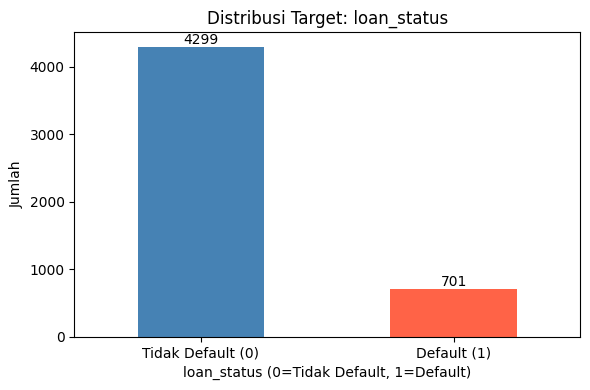

Class distribution:
loan_status
0    4299
1     701
Name: count, dtype: int64


In [6]:
# 3.3 Distribusi Target
fig, ax = plt.subplots(figsize=(6, 4))
df['loan_status'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
ax.set_title('Distribusi Target: loan_status')
ax.set_xlabel('loan_status (0=Tidak Default, 1=Default)')
ax.set_ylabel('Jumlah')
ax.set_xticklabels(['Tidak Default (0)', 'Default (1)'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.savefig('eda_target_distribution.png')
plt.show()
print(f"Class distribution:\n{df['loan_status'].value_counts()}")


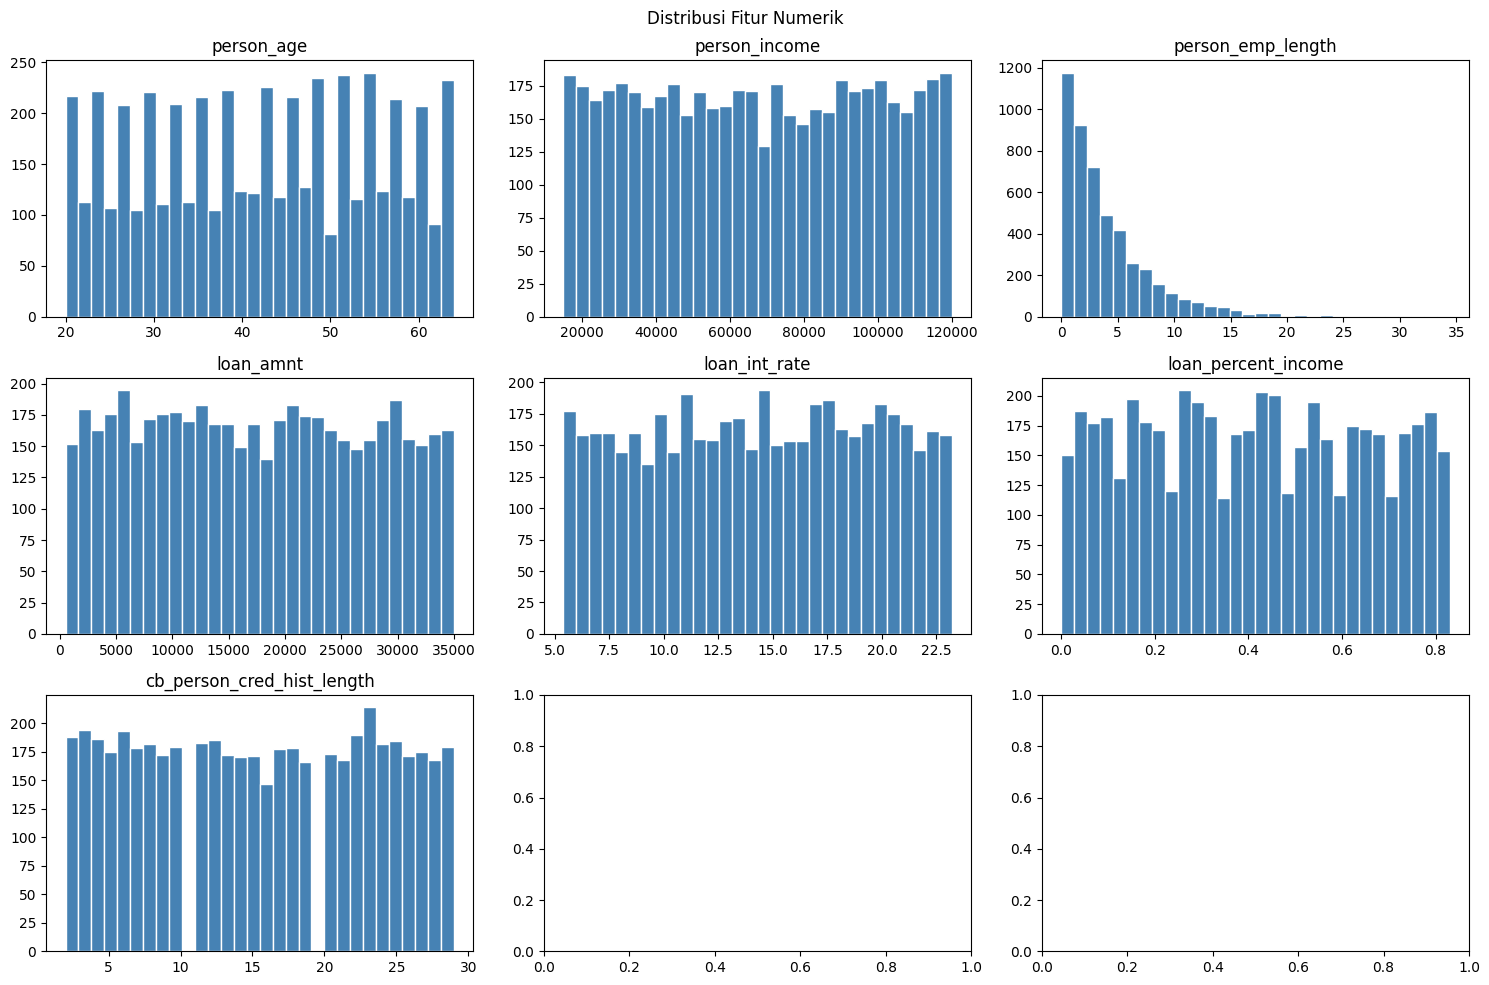

In [7]:
# 3.4 Distribusi Fitur Numerik
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != 'loan_status']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols[:9]):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
plt.suptitle('Distribusi Fitur Numerik')
plt.tight_layout()
plt.savefig('eda_numeric_distribution.png')
plt.show()


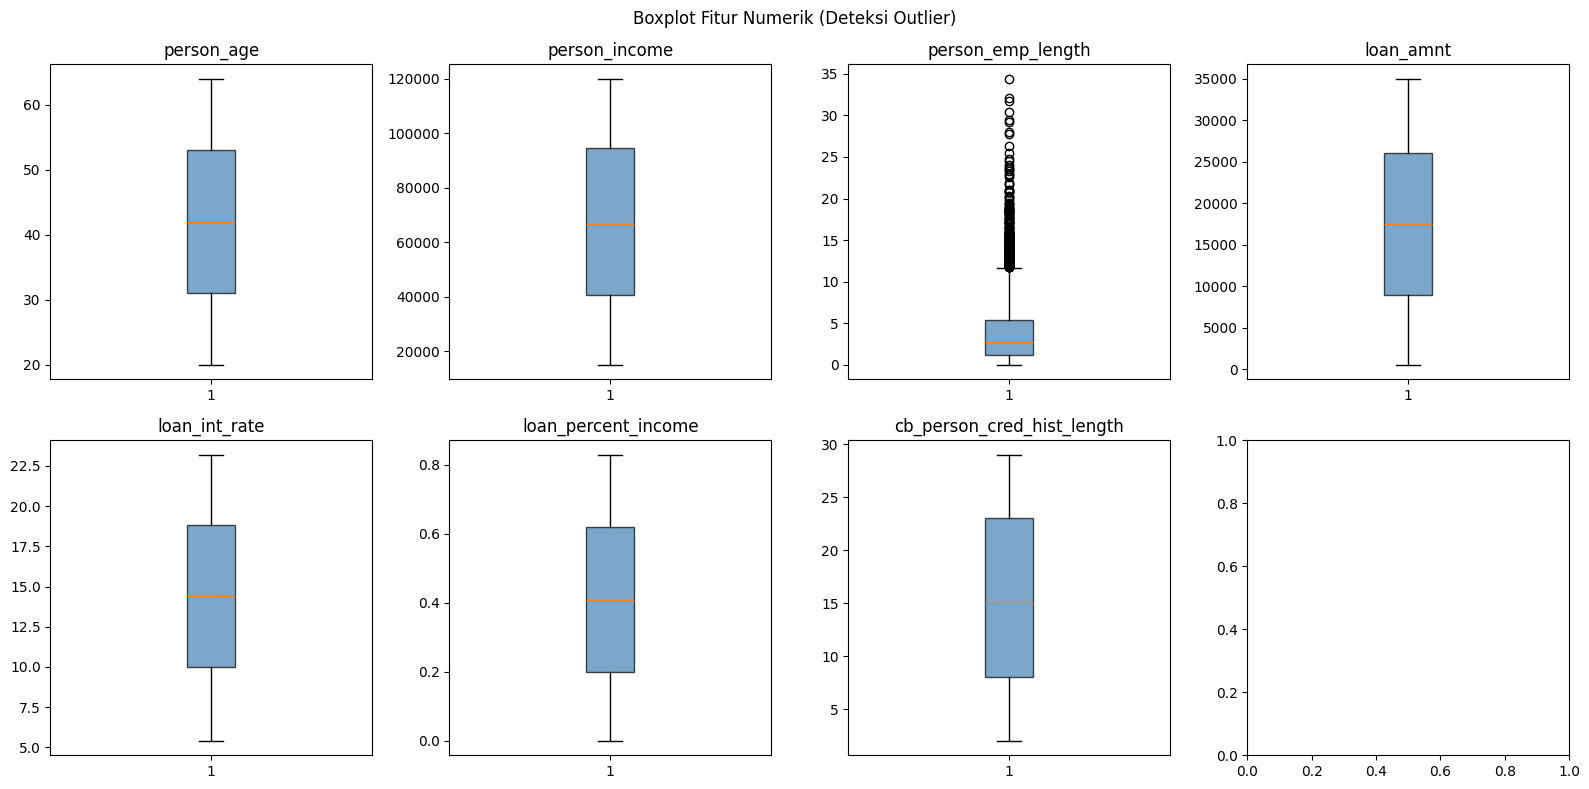

In [8]:
# 3.5 Boxplot (Deteksi Outlier)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols[:8]):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(col)
plt.suptitle('Boxplot Fitur Numerik (Deteksi Outlier)')
plt.tight_layout()
plt.savefig('eda_boxplot.png')
plt.show()


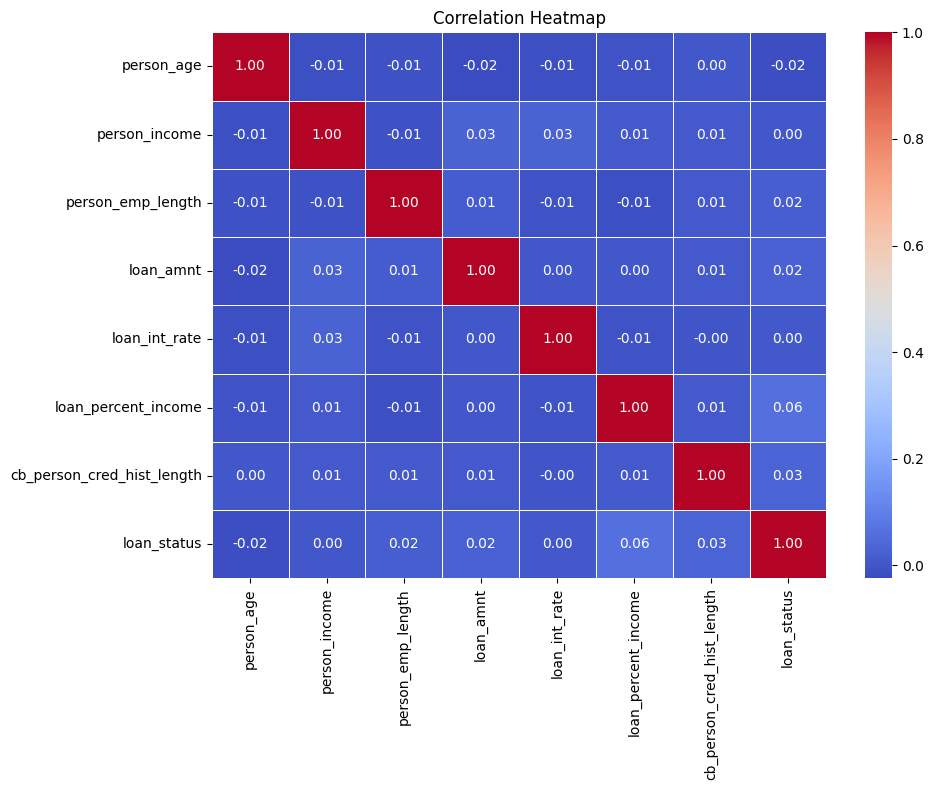

In [9]:
# 3.6 Korelasi antar Fitur Numerik
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[num_cols + ['loan_status']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png')
plt.show()


Fitur kategorikal: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


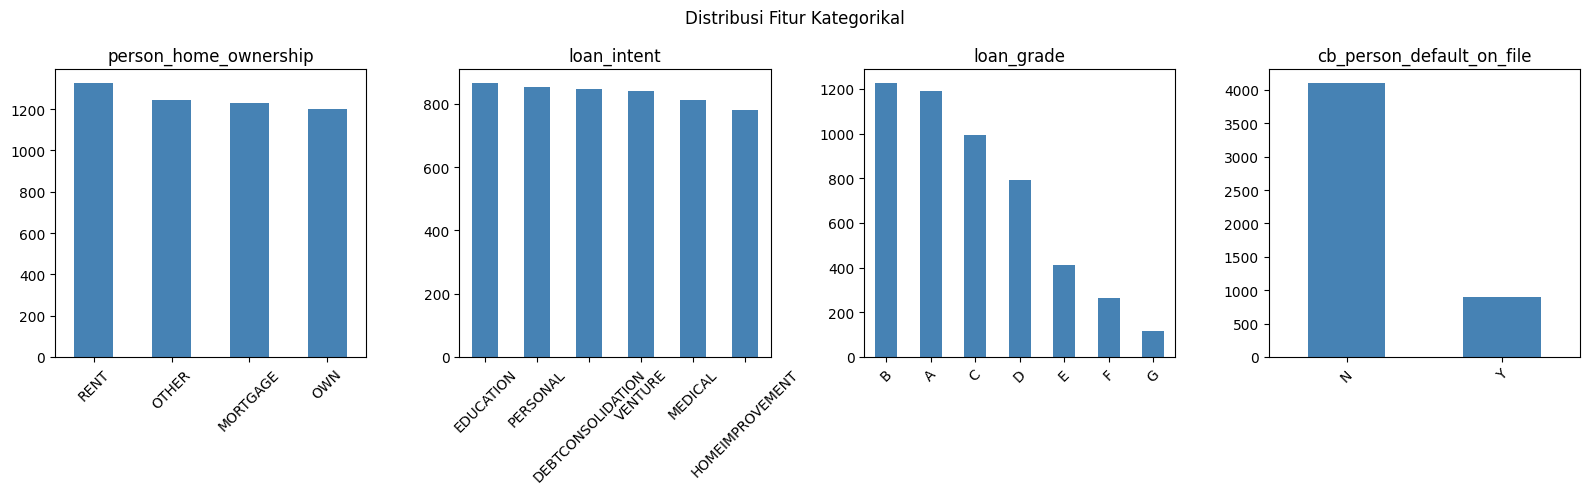

In [10]:
# 3.7 Distribusi Fitur Kategorikal
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Fitur kategorikal: {cat_cols}")

fig, axes = plt.subplots(1, len(cat_cols), figsize=(16, 5))
if len(cat_cols) == 1:
    axes = [axes]
for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
plt.suptitle('Distribusi Fitur Kategorikal')
plt.tight_layout()
plt.savefig('eda_categorical_distribution.png')
plt.show()


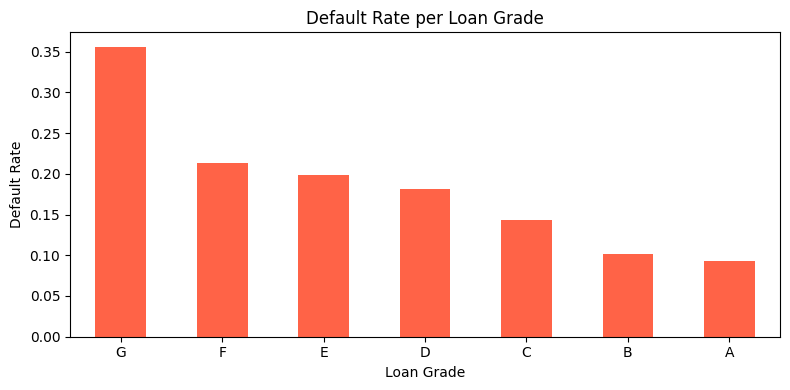

loan_grade
G    0.355932
F    0.212928
E    0.199029
D    0.181360
C    0.142714
B    0.101142
A    0.093121
Name: loan_status, dtype: float64


In [11]:
# 3.8 Default Rate per Kategori loan_grade
default_rate = df.groupby('loan_grade')['loan_status'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
default_rate.plot(kind='bar', ax=ax, color='tomato')
ax.set_title('Default Rate per Loan Grade')
ax.set_ylabel('Default Rate')
ax.set_xlabel('Loan Grade')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('eda_default_rate.png')
plt.show()
print(default_rate)


## 4. Data Preprocessing

In [12]:
# 4.1 Handle Missing Values
df_clean = df.copy()

num_cols_missing = df_clean.select_dtypes(include=np.number).columns[df_clean.select_dtypes(include=np.number).isnull().any()]
if len(num_cols_missing) > 0:
    imputer = SimpleImputer(strategy='median')
    df_clean[num_cols_missing] = imputer.fit_transform(df_clean[num_cols_missing])
    print(f"Diimputasi (median): {list(num_cols_missing)}")

print(f"Missing values setelah imputasi: {df_clean.isnull().sum().sum()}")


Diimputasi (median): ['person_emp_length', 'loan_int_rate']
Missing values setelah imputasi: 0


In [13]:
# 4.2 Handle Duplicates
n_before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Baris sebelum: {n_before} | Setelah: {len(df_clean)} | Hapus: {n_before - len(df_clean)}")


Baris sebelum: 5000 | Setelah: 5000 | Hapus: 0


In [14]:
# 4.3 Handle Outliers (IQR Capping)
outlier_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'cb_person_cred_hist_length']

for col in outlier_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
    print(f"{col:35s}: {n_out} outlier → cap [{lower:.2f}, {upper:.2f}]")


person_age                         : 0 outlier → cap [-2.00, 86.00]
person_income                      : 0 outlier → cap [-40172.50, 175627.50]
person_emp_length                  : 275 outlier → cap [-4.95, 11.45]
loan_amnt                          : 0 outlier → cap [-16870.25, 51823.75]
cb_person_cred_hist_length         : 0 outlier → cap [-14.50, 45.50]


In [15]:
# 4.4 Encoding Fitur Kategorikal

# Ordinal Encoding: loan_grade
grade_order = [['A', 'B', 'C', 'D', 'E', 'F', 'G']]
ord_enc = OrdinalEncoder(categories=grade_order)
df_clean['loan_grade'] = ord_enc.fit_transform(df_clean[['loan_grade']]).ravel()
print("loan_grade → OrdinalEncoder:", sorted(df_clean['loan_grade'].unique()))

# Label Encoding: cb_person_default_on_file
le = LabelEncoder()
df_clean['cb_person_default_on_file'] = le.fit_transform(df_clean['cb_person_default_on_file'])
print("cb_person_default_on_file → LabelEncoder:", df_clean['cb_person_default_on_file'].unique())

# One-Hot Encoding: person_home_ownership, loan_intent
df_clean = pd.get_dummies(df_clean, columns=['person_home_ownership', 'loan_intent'], drop_first=False, dtype=int)
print(f"Shape setelah encoding: {df_clean.shape}")
df_clean.head()


loan_grade → OrdinalEncoder: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0)]
cb_person_default_on_file → LabelEncoder: [0 1]
Shape setelah encoding: (5000, 20)


,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,58,52842,10.5,2.0,6474,14.17,0.39,0,20,0,1,0,0,0,0,0,0,1,0,0
1,48,28900,1.9,0.0,5650,17.18,0.25,0,28,0,0,1,0,0,0,0,1,0,0,0
2,34,95059,1.1,1.0,12632,18.34,0.61,0,25,1,0,1,0,0,0,0,1,0,0,0
3,62,16881,3.2,3.0,18992,19.23,0.70,0,18,0,0,1,0,0,0,0,0,0,1,0
4,27,48037,6.4,0.0,22966,17.35,0.75,0,29,0,0,0,0,1,1,0,0,0,0,0


In [16]:
# 4.5 Feature Scaling & Train-Test Split
X = df_clean.drop('loan_status', axis=1)
y = df_clean['loan_status']

scale_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
              'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'loan_grade']
scale_cols = [c for c in scale_cols if c in X.columns]

scaler = StandardScaler()
X = X.copy()
X[scale_cols] = scaler.fit_transform(X[scale_cols])
print(f"StandardScaler diterapkan pada: {scale_cols}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")


StandardScaler diterapkan pada: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'loan_grade']
X_train: (4000, 19) | X_test: (1000, 19)
y_train: (4000,) | y_test: (1000,)


In [17]:
# 4.6 Simpan Dataset Preprocessing
import os
os.makedirs('credit_scoring_preprocessing', exist_ok=True)

X_train.to_csv('credit_scoring_preprocessing/X_train.csv', index=False)
X_test.to_csv('credit_scoring_preprocessing/X_test.csv', index=False)
y_train.to_csv('credit_scoring_preprocessing/y_train.csv', index=False)
y_test.to_csv('credit_scoring_preprocessing/y_test.csv', index=False)

print("✅ Dataset preprocessing tersimpan!")
print(f"   X_train.csv : {X_train.shape}")
print(f"   X_test.csv  : {X_test.shape}")
print(f"   y_train.csv : {y_train.shape}")
print(f"   y_test.csv  : {y_test.shape}")


✅ Dataset preprocessing tersimpan!
   X_train.csv : (4000, 19)
   X_test.csv  : (1000, 19)
   y_train.csv : (4000,)
   y_test.csv  : (1000,)


## 5. Kesimpulan Eksperimen

### Ringkasan Preprocessing
| Tahap | Keterangan |
|-------|-----------|
| Data Loading | 5000 baris, 12 kolom |
| Missing Values | `person_emp_length` dan `loan_int_rate` diimputasi dengan median |
| Duplikat | Tidak ditemukan duplikat |
| Outlier | IQR capping pada 5 kolom numerik |
| Encoding | OrdinalEncoder (loan_grade), LabelEncoder (cb_person_default_on_file), OHE (person_home_ownership, loan_intent) |
| Scaling | StandardScaler pada 8 kolom numerik |
| Train-Test Split | 80% train (4000), 20% test (1000) dengan stratifikasi |

### Dataset Siap Latih
- **X_train:** (4000, 19)
- **X_test:** (1000, 19)
- **y_train:** (4000,)
- **y_test:** (1000,)
